# MoE Routing & Functional Analysis: Multilingual Models
This notebook analyzes multilingual models to determine whether MoE routing reflects age-linked acoustic specialization (RQ3).


In [6]:
# %% [markdown]
# # Multilingual Routing Analysis (RQ3)
#
# This notebook analyzes whether MoE routing in the multilingual models reflects:
#
# 1. language specialization,
# 2. age specialization within each language,
# 3. shared or language-specific child-speech expert preferences.
#
# Models:
# - adult_moe
# - child_moe_lb_off
# - child_moe_lb_on
#
# Main analysis uses a 4-hour cap per language/age group so that routing comparisons
# are not dominated by larger datasets.

# %%
# Cell 0: Setup

import pandas as pd
import numpy as np
from pathlib import Path
from itertools import combinations
from scipy.spatial.distance import jensenshannon
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# -----------------------------
# Paths
# -----------------------------
ROUTING_DIR = Path("/lp-dev/amelia/inclusive-asr-moe2/analysis/routing/routing_outputs_multilingual")
OUTPUT_DIR = Path("/lp-dev/amelia/inclusive-asr-moe2/analysis/routing/routing_outputs_multilingual_analysis")
OUTPUT_DIR.mkdir(exist_ok=True)

EN_ONLY_DIR = Path("/lp-dev/amelia/inclusive-asr-moe2/analysis/routing/routing_outputs_en")
EN_ONLY_CSV = EN_ONLY_DIR / "child_moe_lb_off_routing.csv"

# -----------------------------
# Constants
# -----------------------------
MODEL_NAMES = ["adult_moe", "child_moe_lb_off", "child_moe_lb_on"]
PRIMARY_MODEL = "child_moe_lb_off"

NUM_LAYERS = 17
NUM_EXPERTS = 8
TOP_K = 2
N_BOOT = 500

TARGET_HOURS = 4
TARGET_SECONDS = TARGET_HOURS * 3600

EXPERT_PROB_COLS = [f"expert_{i}_prob" for i in range(NUM_EXPERTS)]

ALL_LANGUAGES = ["en", "nl", "de", "pl"]
AGE_LANGUAGES = ["en", "nl", "de"]  # PL/PAVSig reported separately

RNG = np.random.default_rng(42)

MODEL_COLORS = {
    "adult_moe": "C4",
    "child_moe_lb_off": "C0",
    "child_moe_lb_on": "C2",
}

LANG_COLORS = {
    "en": "C0",
    "nl": "C1",
    "de": "C2",
    "pl": "C3",
}


def jsd(p, q):
    """Jensen-Shannon Divergence. scipy returns sqrt(JSD), so square it."""
    return jensenshannon(p, q, base=2.0) ** 2


print("ROUTING_DIR:", ROUTING_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("Target duration per group:", TARGET_HOURS, "hours")

ROUTING_DIR: /lp-dev/amelia/inclusive-asr-moe2/analysis/routing/routing_outputs_multilingual
OUTPUT_DIR: /lp-dev/amelia/inclusive-asr-moe2/analysis/routing/routing_outputs_multilingual_analysis
Target duration per group: 4 hours


In [7]:
# %%
# Cell 1: Load routing CSVs

def get_expert_prob_cols(df: pd.DataFrame) -> list[str]:
    """Return expert probability columns sorted by expert index."""
    cols = [
        c for c in df.columns
        if c.startswith("expert_") and c.endswith("_prob")
    ]
    return sorted(cols, key=lambda x: int(x.split("_")[1]))


def load_routing_csv(path: Path, name: str, expected_experts: int | None = None) -> pd.DataFrame | None:
    if not path.exists():
        print(f"WARNING: missing {name} at {path}")
        return None

    df = pd.read_csv(path)

    prob_cols = get_expert_prob_cols(df)

    required_base_cols = [
        "utterance_id",
        "age_group",
        "language",
        "dataset_source",
        "layer_idx",
        "top1_expert",
        "duration_sec",
        "model",
    ]

    missing = [c for c in required_base_cols if c not in df.columns]
    if missing:
        print(f"WARNING: {name} missing columns: {missing}")

    if expected_experts is not None and len(prob_cols) != expected_experts:
        print(
            f"WARNING: {name} has {len(prob_cols)} expert prob columns, "
            f"expected {expected_experts}"
        )

    if "top2_expert" not in df.columns:
        print(f"WARNING: {name} missing top2_expert; continuing anyway")

    print(f"  {name}: {df.shape[0]:,} rows, {df.shape[1]} cols, experts={len(prob_cols)}")
    return df


print("Loading multilingual routing CSVs...")
routing_dfs = {}

for model_name in MODEL_NAMES:
    path = ROUTING_DIR / f"{model_name}_routing.csv"
    routing_dfs[model_name] = load_routing_csv(path, model_name, expected_experts=NUM_EXPERTS)


print("\nLoading English-only model CSV...")
en_only_df = load_routing_csv(EN_ONLY_CSV, "english_child_moe_lb_off", expected_experts=4)


print("\n--- Sanity check: multilingual files ---")
for model_name, df in routing_dfs.items():
    if df is None or df.empty:
        print(f"{model_name}: missing/empty")
        continue

    layer0 = df[df["layer_idx"] == 0].copy()

    print(f"\n{model_name}")
    print("Utterances per language/age:")
    print(
        layer0.groupby(["language", "age_group"])["utterance_id"]
        .nunique()
        .reset_index(name="n_utterances")
        .to_string(index=False)
    )

    print("Duration per language/age, hours:")
    dur = (
        layer0.groupby(["language", "age_group"])["duration_sec"]
        .sum()
        .div(3600)
        .reset_index(name="hours")
    )
    print(dur.to_string(index=False))

Loading multilingual routing CSVs...
  adult_moe: 180,217 rows, 18 cols, experts=8
  child_moe_lb_off: 180,217 rows, 18 cols, experts=8
  child_moe_lb_on: 180,217 rows, 18 cols, experts=8

Loading English-only model CSV...
  english_child_moe_lb_off: 268,413 rows, 14 cols, experts=4

--- Sanity check: multilingual files ---

adult_moe
Utterances per language/age:
language age_group  n_utterances
      de     adult          1500
      de     child          1500
      en     adult          1500
      en     child          1500
      nl     adult          1500
      nl     child          1095
      pl     adult          1500
      pl     child           506
Duration per language/age, hours:
language age_group    hours
      de     adult 2.460166
      de     child 1.287966
      en     adult 3.176800
      en     child 3.776894
      nl     adult 1.948058
      nl     child 0.539313
      pl     adult 2.035387
      pl     child 0.134852

child_moe_lb_off
Utterances per language/age:
lang

In [8]:
# %%
# Cell 2: 4-hour capped analysis sets
#
# Important:
# Each utterance appears once per layer, so sampling must happen at the utterance level.
# We sample using layer_idx == 0 as the utterance table, then keep all 17 rows.

def sample_utterances_to_duration(
    df: pd.DataFrame,
    target_seconds: float,
    rng: np.random.Generator,
    group_name: str = "",
) -> pd.DataFrame:
    """
    Sample whole utterances without replacement until target duration is reached.
    Keeps all layer rows for selected utterances.
    """
    if df is None or df.empty:
        return df.iloc[0:0]

    utt = (
        df[df["layer_idx"] == 0]
        [["utterance_id", "duration_sec"]]
        .drop_duplicates("utterance_id")
        .copy()
    )

    utt["duration_sec"] = utt["duration_sec"].astype(float)
    utt = utt.dropna(subset=["duration_sec"])

    if utt.empty:
        return df.iloc[0:0]

    utt = utt.sample(frac=1.0, random_state=int(rng.integers(0, 1_000_000_000)))

    picked = []
    total = 0.0

    for _, row in utt.iterrows():
        picked.append(row["utterance_id"])
        total += float(row["duration_sec"])
        if total >= target_seconds:
            break

    selected = df[df["utterance_id"].isin(picked)].copy()

    print(
        f"{group_name}: selected {len(picked):,}/{len(utt):,} utterances, "
        f"{total / 3600:.2f} hours"
    )

    return selected


def make_4h_capped_df(
    df: pd.DataFrame,
    group_cols: list[str],
    target_seconds: float,
    rng: np.random.Generator,
) -> pd.DataFrame:
    """
    Build a duration-capped dataframe per group.
    Example group_cols:
      ["language", "age_group"]
      ["language"]
    """
    parts = []

    for group_key, group_df in df.groupby(group_cols):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)
        group_name = "/".join(str(x) for x in group_key)

        part = sample_utterances_to_duration(
            group_df,
            target_seconds=target_seconds,
            rng=rng,
            group_name=group_name,
        )
        if not part.empty:
            parts.append(part)

    if not parts:
        return df.iloc[0:0].copy()

    return pd.concat(parts, ignore_index=True)


# Main capped set: per model, cap each language/age group at 4h.
routing_dfs_4h = {}

print("\nBuilding 4-hour capped sets per (language, age_group)...")
for model_name, df in routing_dfs.items():
    if df is None or df.empty:
        routing_dfs_4h[model_name] = df
        continue

    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)

    routing_dfs_4h[model_name] = make_4h_capped_df(
        df,
        group_cols=["language", "age_group"],
        target_seconds=TARGET_SECONDS,
        rng=RNG,
    )

print("\n--- 4-hour capped set summary ---")
for model_name, df in routing_dfs_4h.items():
    if df is None or df.empty:
        continue

    layer0 = df[df["layer_idx"] == 0]
    print(f"\n{model_name}")
    print(
        layer0.groupby(["language", "age_group"])
        .agg(
            n_utterances=("utterance_id", "nunique"),
            hours=("duration_sec", lambda x: x.sum() / 3600),
        )
        .reset_index()
        .to_string(index=False)
    )


Building 4-hour capped sets per (language, age_group)...

adult_moe
de/adult: selected 1,500/1,500 utterances, 2.46 hours
de/child: selected 1,500/1,500 utterances, 1.29 hours
en/adult: selected 1,500/1,500 utterances, 3.18 hours
en/child: selected 1,500/1,500 utterances, 3.78 hours
nl/adult: selected 1,500/1,500 utterances, 1.95 hours
nl/child: selected 1,095/1,095 utterances, 0.54 hours
pl/adult: selected 1,500/1,500 utterances, 2.04 hours
pl/child: selected 506/506 utterances, 0.13 hours

child_moe_lb_off
de/adult: selected 1,500/1,500 utterances, 2.46 hours
de/child: selected 1,500/1,500 utterances, 1.29 hours
en/adult: selected 1,500/1,500 utterances, 3.18 hours
en/child: selected 1,500/1,500 utterances, 3.78 hours
nl/adult: selected 1,500/1,500 utterances, 1.95 hours
nl/child: selected 1,095/1,095 utterances, 0.54 hours
pl/adult: selected 1,500/1,500 utterances, 2.04 hours
pl/child: selected 506/506 utterances, 0.13 hours

child_moe_lb_on
de/adult: selected 1,500/1,500 utterance

In [9]:
# %%
# Cell 3: Distribution helpers

def weighted_distribution(group_df: pd.DataFrame, prob_cols: list[str] = EXPERT_PROB_COLS) -> np.ndarray | None:
    """
    Duration-weighted routing distribution over experts.
    Assumes group_df contains one row per utterance-layer.
    """
    if group_df is None or group_df.empty:
        return None

    probs = group_df[prob_cols].values.astype(float)

    if "duration_sec" in group_df.columns:
        weights = group_df["duration_sec"].values.astype(float)
        totals = (probs * weights[:, None]).sum(axis=0)
    else:
        totals = probs.sum(axis=0)

    denom = totals.sum()
    if denom == 0:
        return np.zeros(len(prob_cols))

    return totals / denom


def layer_distributions(df: pd.DataFrame, prob_cols: list[str] = EXPERT_PROB_COLS) -> dict[int, np.ndarray]:
    out = {}
    for layer_idx, layer_df in df.groupby("layer_idx"):
        out[int(layer_idx)] = weighted_distribution(layer_df, prob_cols=prob_cols)
    return out


def build_distributions_by_lang_age(
    dfs: dict[str, pd.DataFrame],
    prob_cols: list[str] = EXPERT_PROB_COLS,
) -> dict:
    """
    distributions[model][layer][(language, age_group)] = expert distribution
    """
    distributions = {}

    for model_name, df in dfs.items():
        if df is None or df.empty:
            distributions[model_name] = {}
            continue

        model_dist = {}

        for layer_idx, layer_df in df.groupby("layer_idx"):
            model_dist[int(layer_idx)] = {}

            for (lang, age), group_df in layer_df.groupby(["language", "age_group"]):
                model_dist[int(layer_idx)][(lang, age)] = weighted_distribution(
                    group_df,
                    prob_cols=prob_cols,
                )

        distributions[model_name] = model_dist

    return distributions


# Use the 4h-capped distributions for the main analysis.
distributions = build_distributions_by_lang_age(routing_dfs_4h)

print("Distribution check:")
for model_name in MODEL_NAMES:
    md = distributions.get(model_name, {})
    if not md:
        print(f"  {model_name}: no distributions")
        continue

    layer0 = sorted(md.keys())[0]
    key0 = sorted(md[layer0].keys())[0]
    vec = md[layer0][key0]
    print(f"  {model_name}, layer {layer0}, {key0}: sum={vec.sum():.6f}, first={np.round(vec[:4], 4)}")

Distribution check:
  adult_moe, layer 0, ('de', 'adult'): sum=1.000000, first=[0.1482 0.208  0.0937 0.1004]
  child_moe_lb_off, layer 0, ('de', 'adult'): sum=1.000000, first=[0.163  0.2696 0.0636 0.0405]
  child_moe_lb_on, layer 0, ('de', 'adult'): sum=1.000000, first=[0.1794 0.2521 0.069  0.0635]


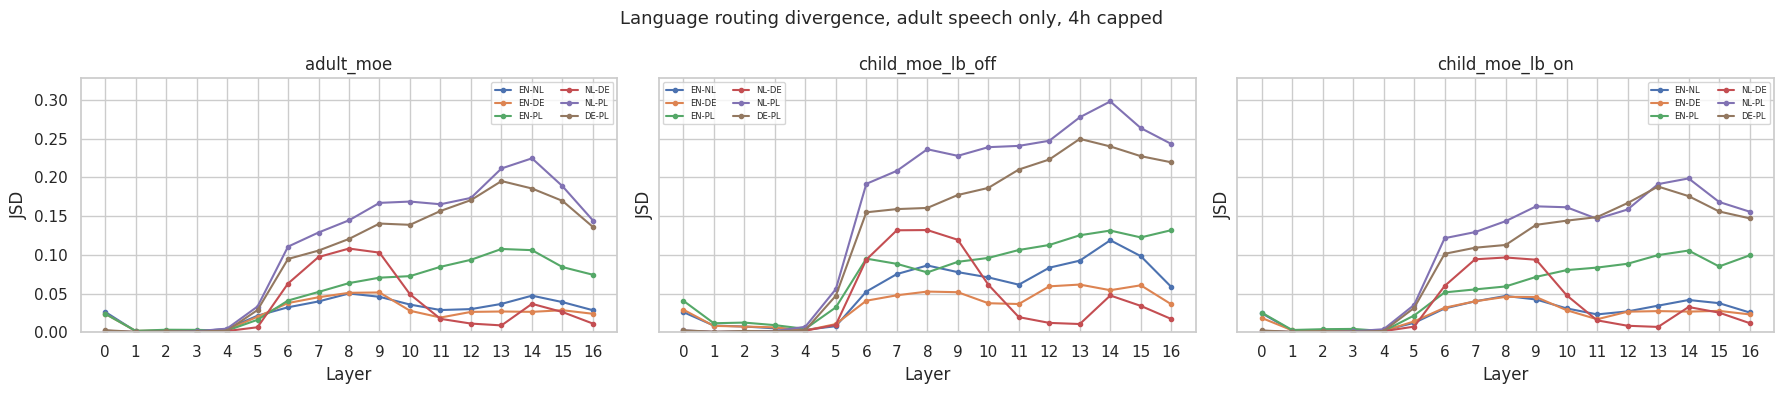


Mean adult-language JSD per pair, child_moe_lb_off:
  EN-NL: mean=0.054924, peak=0.118866
  EN-DE: mean=0.035452, peak=0.061604
  EN-PL: mean=0.075788, peak=0.131875
  NL-DE: mean=0.040819, peak=0.132021
  NL-PL: mean=0.161375, peak=0.298226
  DE-PL: mean=0.133226, peak=0.249822


In [ ]:
# %%
# Cell 4: Language specialization — adult-only pairwise JSD per model
#
# This plot is per model. It compares adult speech across languages.

lang_pairs = list(combinations(ALL_LANGUAGES, 2))
lang_pair_labels = [f"{a.upper()}-{b.upper()}" for a, b in lang_pairs]

lang_jsd_by_model = {}

for model_name in MODEL_NAMES:
    md = distributions.get(model_name, {})
    lang_jsd_by_model[model_name] = {}

    for (lang_a, lang_b), label in zip(lang_pairs, lang_pair_labels):
        vals = []

        for layer in range(NUM_LAYERS):
            ld = md.get(layer, {})
            a = ld.get((lang_a, "adult"))
            b = ld.get((lang_b, "adult"))

            vals.append(jsd(a, b) if a is not None and b is not None else np.nan)

        lang_jsd_by_model[model_name][label] = vals


all_vals = [
    v
    for model_dict in lang_jsd_by_model.values()
    for vals in model_dict.values()
    for v in vals
    if not np.isnan(v)
]
lang_ymax = max(all_vals) * 1.1 if all_vals else 0.01

fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(18, 4), sharey=True)

for ax, model_name in zip(axes, MODEL_NAMES):
    for label, vals in lang_jsd_by_model[model_name].items():
        ax.plot(range(NUM_LAYERS), vals, marker="o", markersize=3, label=label)

    ax.set_title(model_name)
    ax.set_xlabel("Layer")
    ax.set_ylabel("JSD")
    ax.set_xticks(range(NUM_LAYERS))
    ax.set_ylim(0, lang_ymax)
    ax.legend(fontsize=6, ncol=2)

plt.suptitle("Language routing divergence, adult speech only, 4h capped", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "language_pairwise_jsd_all_models_4h.png", dpi=200)
plt.show()


print(f"\nMean adult-language JSD per pair, {PRIMARY_MODEL}:")
for label, vals in lang_jsd_by_model[PRIMARY_MODEL].items():
    valid = np.array([v for v in vals if not np.isnan(v)])
    print(f"  {label}: mean={valid.mean():.6f}, peak={valid.max():.6f}")

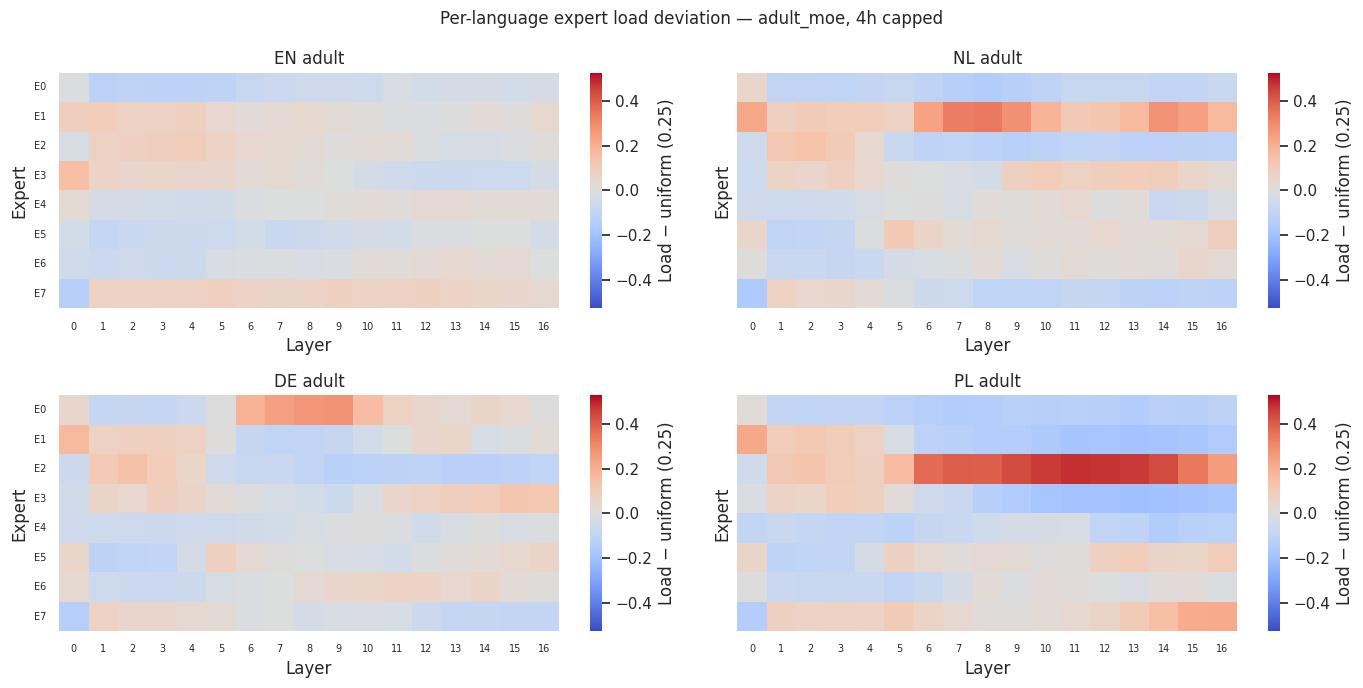

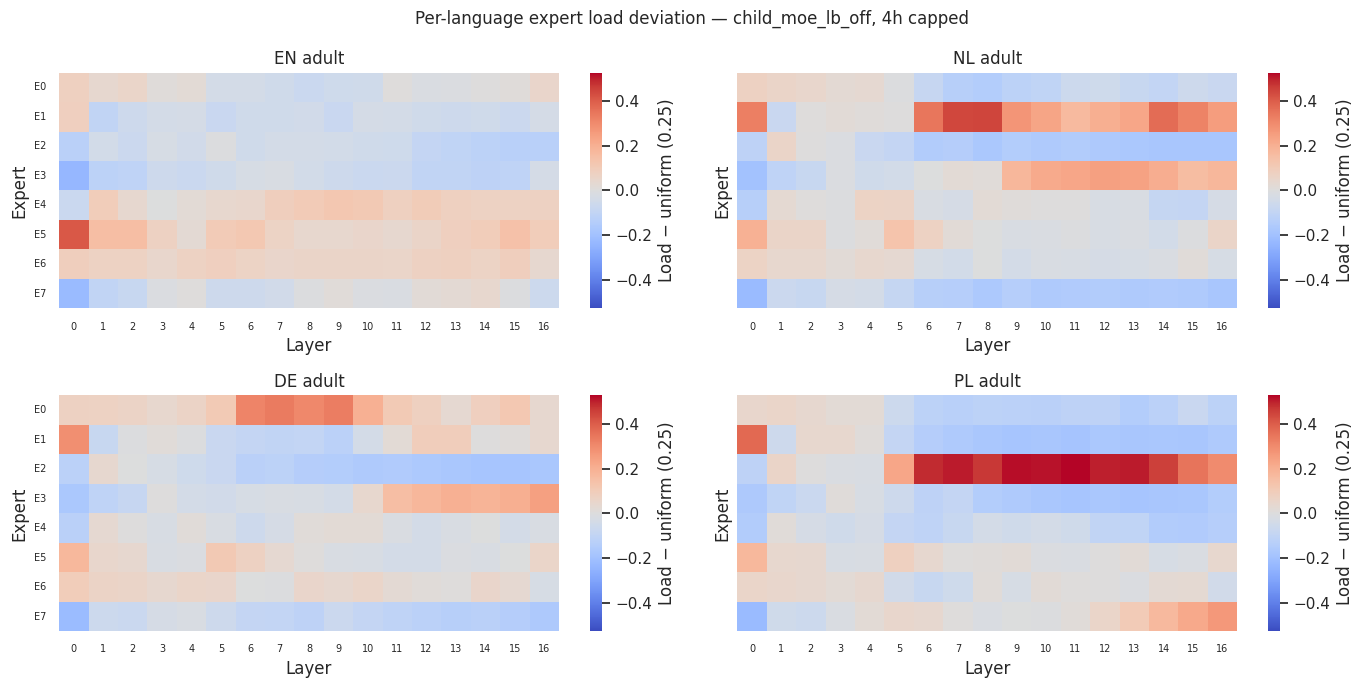

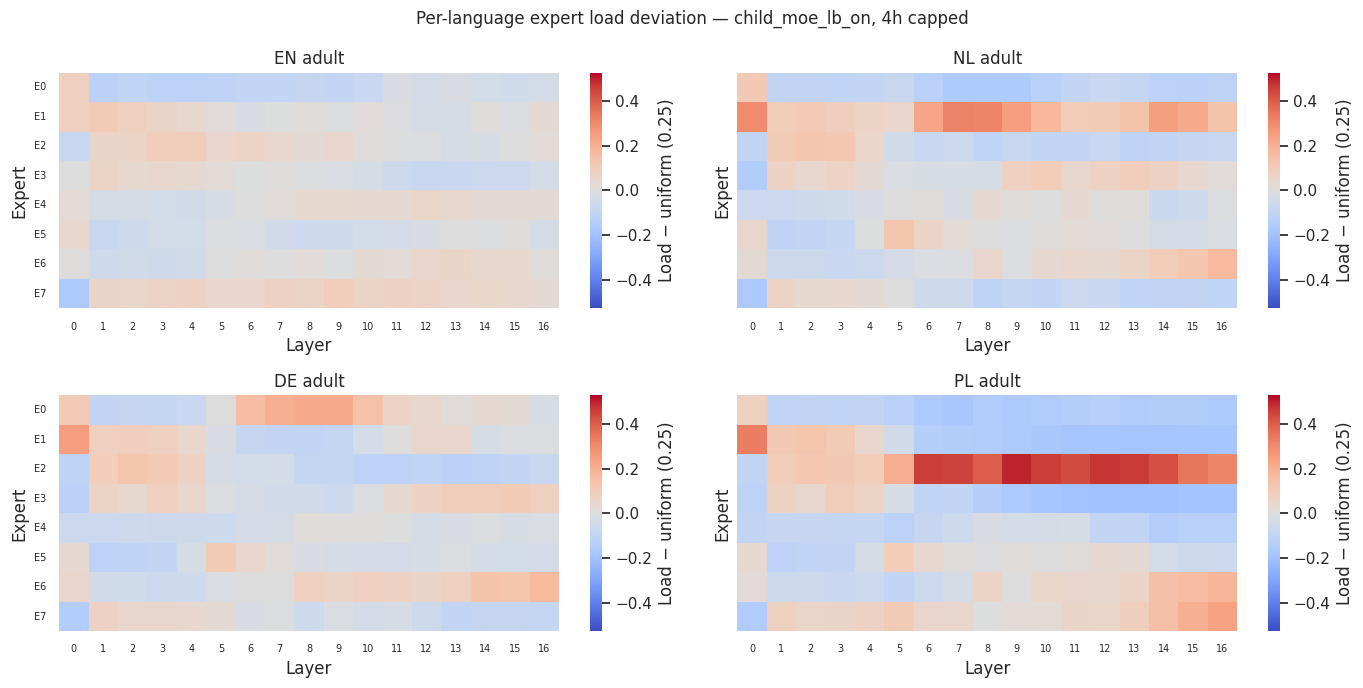

In [11]:
# %%
# Cell 5: Language specialization — expert load per model and language
#
# One figure per model.
# Each figure contains one heatmap per adult language.
# Values are load deviation from uniform, where uniform load = TOP_K / NUM_EXPERTS.

UNIFORM_LOAD = TOP_K / NUM_EXPERTS

language_load_deviation = {}

for model_name in MODEL_NAMES:
    md = distributions.get(model_name, {})
    language_load_deviation[model_name] = {}

    for lang in ALL_LANGUAGES:
        mat = np.full((NUM_EXPERTS, NUM_LAYERS), np.nan)

        for layer in range(NUM_LAYERS):
            dist = md.get(layer, {}).get((lang, "adult"))

            if dist is not None:
                mat[:, layer] = (dist * TOP_K) - UNIFORM_LOAD

        language_load_deviation[model_name][lang] = mat


all_devs = []
for model_dict in language_load_deviation.values():
    for mat in model_dict.values():
        all_devs.extend(mat.ravel())

all_devs = np.array([x for x in all_devs if not np.isnan(x)])
max_dev = np.max(np.abs(all_devs)) if all_devs.size else 1e-6
if max_dev == 0:
    max_dev = 1e-6


for model_name in MODEL_NAMES:
    fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey=True)

    for ax, lang in zip(axes.ravel(), ALL_LANGUAGES):
        mat = language_load_deviation[model_name][lang]

        sns.heatmap(
            mat,
            cmap="coolwarm",
            center=0,
            vmin=-max_dev,
            vmax=max_dev,
            ax=ax,
            cbar_kws={"label": f"Load − uniform ({UNIFORM_LOAD:.2f})"},
        )

        ax.set_title(f"{lang.upper()} adult")
        ax.set_xlabel("Layer")
        ax.set_ylabel("Expert")
        ax.set_xticks(np.arange(NUM_LAYERS) + 0.5)
        ax.set_xticklabels(range(NUM_LAYERS), fontsize=7)
        ax.set_yticklabels([f"E{i}" for i in range(NUM_EXPERTS)], rotation=0, fontsize=7)

    plt.suptitle(f"Per-language expert load deviation — {model_name}, 4h capped", fontsize=12)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"language_expert_load_{model_name}_4h.png", dpi=200)
    plt.show()

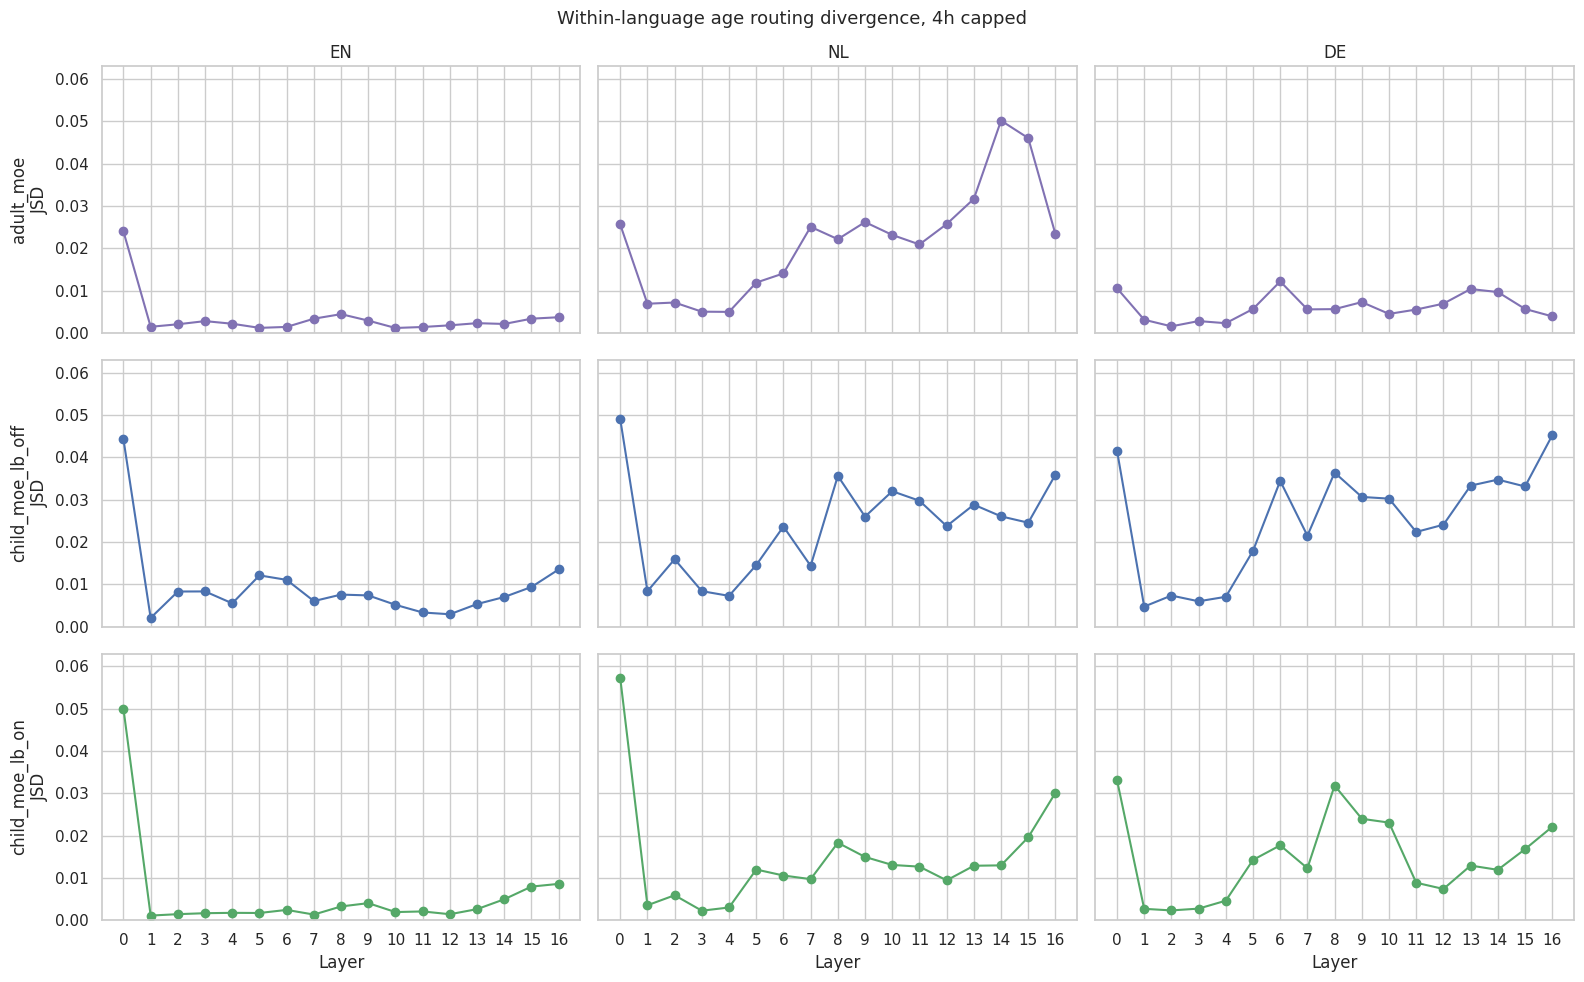


Peak age JSD, 4h capped:
  adult_moe/EN: peak=0.023976, layer=0
  adult_moe/NL: peak=0.050171, layer=14
  adult_moe/DE: peak=0.012185, layer=6
  child_moe_lb_off/EN: peak=0.044262, layer=0
  child_moe_lb_off/NL: peak=0.049047, layer=0
  child_moe_lb_off/DE: peak=0.045183, layer=16
  child_moe_lb_on/EN: peak=0.049980, layer=0
  child_moe_lb_on/NL: peak=0.057268, layer=0
  child_moe_lb_on/DE: peak=0.033142, layer=0


In [12]:
# %%
# Cell 6: Age specialization — observed JSD per model and language
#
# This is NOT averaged. It plots each model/language separately.
# Main clean plot: grid with rows=models, columns=languages.

age_jsd_observed = {}

for model_name in MODEL_NAMES:
    md = distributions.get(model_name, {})

    for lang in AGE_LANGUAGES:
        vals = []

        for layer in range(NUM_LAYERS):
            ld = md.get(layer, {})
            adult = ld.get((lang, "adult"))
            child = ld.get((lang, "child"))

            vals.append(jsd(adult, child) if adult is not None and child is not None else np.nan)

        age_jsd_observed[(model_name, lang)] = vals


all_age_vals = [
    v for vals in age_jsd_observed.values()
    for v in vals
    if not np.isnan(v)
]
age_ymax = max(all_age_vals) * 1.1 if all_age_vals else 0.01

fig, axes = plt.subplots(
    len(MODEL_NAMES),
    len(AGE_LANGUAGES),
    figsize=(16, 10),
    sharex=True,
    sharey=True,
)

for r, model_name in enumerate(MODEL_NAMES):
    for c, lang in enumerate(AGE_LANGUAGES):
        ax = axes[r, c]
        vals = age_jsd_observed[(model_name, lang)]

        ax.plot(range(NUM_LAYERS), vals, marker="o", color=MODEL_COLORS[model_name])
        ax.set_ylim(0, age_ymax)
        ax.set_xticks(range(NUM_LAYERS))

        if r == 0:
            ax.set_title(lang.upper())

        if c == 0:
            ax.set_ylabel(f"{model_name}\nJSD")

        if r == len(MODEL_NAMES) - 1:
            ax.set_xlabel("Layer")

plt.suptitle("Within-language age routing divergence, 4h capped", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "age_jsd_grid_models_languages_4h.png", dpi=200)
plt.show()


print("\nPeak age JSD, 4h capped:")
for model_name in MODEL_NAMES:
    for lang in AGE_LANGUAGES:
        vals = age_jsd_observed[(model_name, lang)]
        valid = [(i, v) for i, v in enumerate(vals) if not np.isnan(v)]
        if valid:
            peak_layer, peak_val = max(valid, key=lambda x: x[1])
            print(f"  {model_name}/{lang.upper()}: peak={peak_val:.6f}, layer={peak_layer}")

In [ ]:
# # %%
# # Cell 7: Bootstrap CIs for age JSD
# #
# # Bootstrap is done at utterance level, not row level.
# # This avoids accidentally sampling layer rows independently.

# def bootstrap_sample_whole_utterances(
#     df: pd.DataFrame,
#     rng: np.random.Generator,
#     n_utterances: int | None = None,
# ) -> pd.DataFrame:
#     """
#     Sample utterances with replacement and keep all layer rows.
#     This preserves row duplication if an utterance is sampled multiple times.
#     """
#     if df is None or df.empty:
#         return df.iloc[0:0]

#     utt_ids = (
#         df[df["layer_idx"] == 0]["utterance_id"]
#         .drop_duplicates()
#         .to_numpy()
#     )

#     if n_utterances is None:
#         n_utterances = len(utt_ids)

#     sampled_ids = rng.choice(utt_ids, size=n_utterances, replace=True)

#     parts = []
#     for i, utt_id in enumerate(sampled_ids):
#         part = df[df["utterance_id"] == utt_id].copy()
#         # Make duplicated bootstrap utterances unique so groupby does not collapse them later.
#         part["bootstrap_utt_id"] = f"{utt_id}__boot{i}"
#         parts.append(part)

#     return pd.concat(parts, ignore_index=True)


# age_jsd_ci = {}

# for model_name in MODEL_NAMES:
#     df = routing_dfs_4h.get(model_name)

#     if df is None or df.empty:
#         continue

#     for lang in AGE_LANGUAGES:
#         adult_df = df[(df["language"] == lang) & (df["age_group"] == "adult")]
#         child_df = df[(df["language"] == lang) & (df["age_group"] == "child")]

#         if adult_df.empty or child_df.empty:
#             print(f"Skipping bootstrap: {model_name}/{lang.upper()} missing data")
#             continue

#         n_adult = adult_df[adult_df["layer_idx"] == 0]["utterance_id"].nunique()
#         n_child = child_df[child_df["layer_idx"] == 0]["utterance_id"].nunique()

#         boot = np.full((N_BOOT, NUM_LAYERS), np.nan)

#         for b in range(N_BOOT):
#             a_sample = bootstrap_sample_whole_utterances(adult_df, RNG, n_adult)
#             c_sample = bootstrap_sample_whole_utterances(child_df, RNG, n_child)

#             a_dists = layer_distributions(a_sample)
#             c_dists = layer_distributions(c_sample)

#             for layer in range(NUM_LAYERS):
#                 a = a_dists.get(layer)
#                 c = c_dists.get(layer)

#                 if a is not None and c is not None:
#                     boot[b, layer] = jsd(a, c)

#         rows = []
#         for layer in range(NUM_LAYERS):
#             vals = boot[:, layer]
#             vals = vals[~np.isnan(vals)]

#             if vals.size == 0:
#                 rows.append({"layer": layer, "ci_low": np.nan, "ci_high": np.nan})
#             else:
#                 rows.append({
#                     "layer": layer,
#                     "ci_low": float(np.percentile(vals, 2.5)),
#                     "ci_high": float(np.percentile(vals, 97.5)),
#                 })

#         age_jsd_ci[(model_name, lang)] = pd.DataFrame(rows)
#         print(f"Bootstrap done: {model_name}/{lang.upper()}")

KeyboardInterrupt: 

In [14]:
# %%
# Cell 7: Bootstrap CIs for age JSD (fast version)

def bootstrap_jsd_fast(
    adult_df: pd.DataFrame,
    child_df: pd.DataFrame,
    n_boot: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Fast bootstrap: precompute per-utterance expert prob arrays,
    then resample indices and sum. No DataFrame operations in the loop.
    
    Returns: (n_boot, NUM_LAYERS) array of JSD values.
    """
    # Precompute: for each group, build a dict layer -> (n_utterances, n_experts)
    # where each row is the duration-weighted expert probs for one utterance at one layer.
    
    def precompute(df):
        """Returns {layer: array of shape (n_utterances, n_experts)}"""
        # Get unique utterance IDs (from layer 0)
        utt_ids = df[df["layer_idx"] == 0]["utterance_id"].unique()
        utt_to_idx = {uid: i for i, uid in enumerate(utt_ids)}
        n_utt = len(utt_ids)
        
        per_layer = {}
        for layer_idx, layer_df in df.groupby("layer_idx"):
            mat = np.zeros((n_utt, NUM_EXPERTS))
            for _, row in layer_df.iterrows():
                uid = row["utterance_id"]
                if uid not in utt_to_idx:
                    continue
                i = utt_to_idx[uid]
                dur = float(row["duration_sec"]) if "duration_sec" in row.index else 1.0
                probs = row[EXPERT_PROB_COLS].values.astype(float)
                mat[i] = probs * dur
            per_layer[int(layer_idx)] = mat
        
        return per_layer, n_utt
    
    adult_layers, n_adult = precompute(adult_df)
    child_layers, n_child = precompute(child_df)
    
    boot_jsd = np.full((n_boot, NUM_LAYERS), np.nan)
    
    for b in range(n_boot):
        a_idx = rng.integers(0, n_adult, size=n_adult)
        c_idx = rng.integers(0, n_child, size=n_child)
        
        for layer in range(NUM_LAYERS):
            a_mat = adult_layers.get(layer)
            c_mat = child_layers.get(layer)
            if a_mat is None or c_mat is None:
                continue
            
            a_sum = a_mat[a_idx].sum(axis=0)
            c_sum = c_mat[c_idx].sum(axis=0)
            
            a_denom = a_sum.sum()
            c_denom = c_sum.sum()
            if a_denom == 0 or c_denom == 0:
                continue
            
            boot_jsd[b, layer] = jsd(a_sum / a_denom, c_sum / c_denom)
    
    return boot_jsd


age_jsd_ci = {}

for model_name in MODEL_NAMES:
    df = routing_dfs_4h.get(model_name)
    if df is None or df.empty:
        continue

    for lang in AGE_LANGUAGES:
        adult_df = df[(df["language"] == lang) & (df["age_group"] == "adult")]
        child_df = df[(df["language"] == lang) & (df["age_group"] == "child")]

        if adult_df.empty or child_df.empty:
            print(f"  Skipping {model_name}/{lang.upper()}: missing data")
            continue

        print(f"  Bootstrapping {model_name}/{lang.upper()}...", end=" ", flush=True)
        
        boot_jsd = bootstrap_jsd_fast(adult_df, child_df, N_BOOT, RNG)

        ci_rows = []
        for layer in range(NUM_LAYERS):
            vals = boot_jsd[:, layer]
            vals = vals[~np.isnan(vals)]
            if vals.size == 0:
                ci_rows.append({"layer": layer, "ci_low": np.nan, "ci_high": np.nan})
            else:
                ci_rows.append({
                    "layer": layer,
                    "ci_low": float(np.percentile(vals, 2.5)),
                    "ci_high": float(np.percentile(vals, 97.5)),
                })

        age_jsd_ci[(model_name, lang)] = pd.DataFrame(ci_rows)
        print("done")

  Bootstrapping adult_moe/EN... done
  Bootstrapping adult_moe/NL... done
  Bootstrapping adult_moe/DE... done
  Bootstrapping child_moe_lb_off/EN... done
  Bootstrapping child_moe_lb_off/NL... done
  Bootstrapping child_moe_lb_off/DE... done
  Bootstrapping child_moe_lb_on/EN... done
  Bootstrapping child_moe_lb_on/NL... done
  Bootstrapping child_moe_lb_on/DE... done


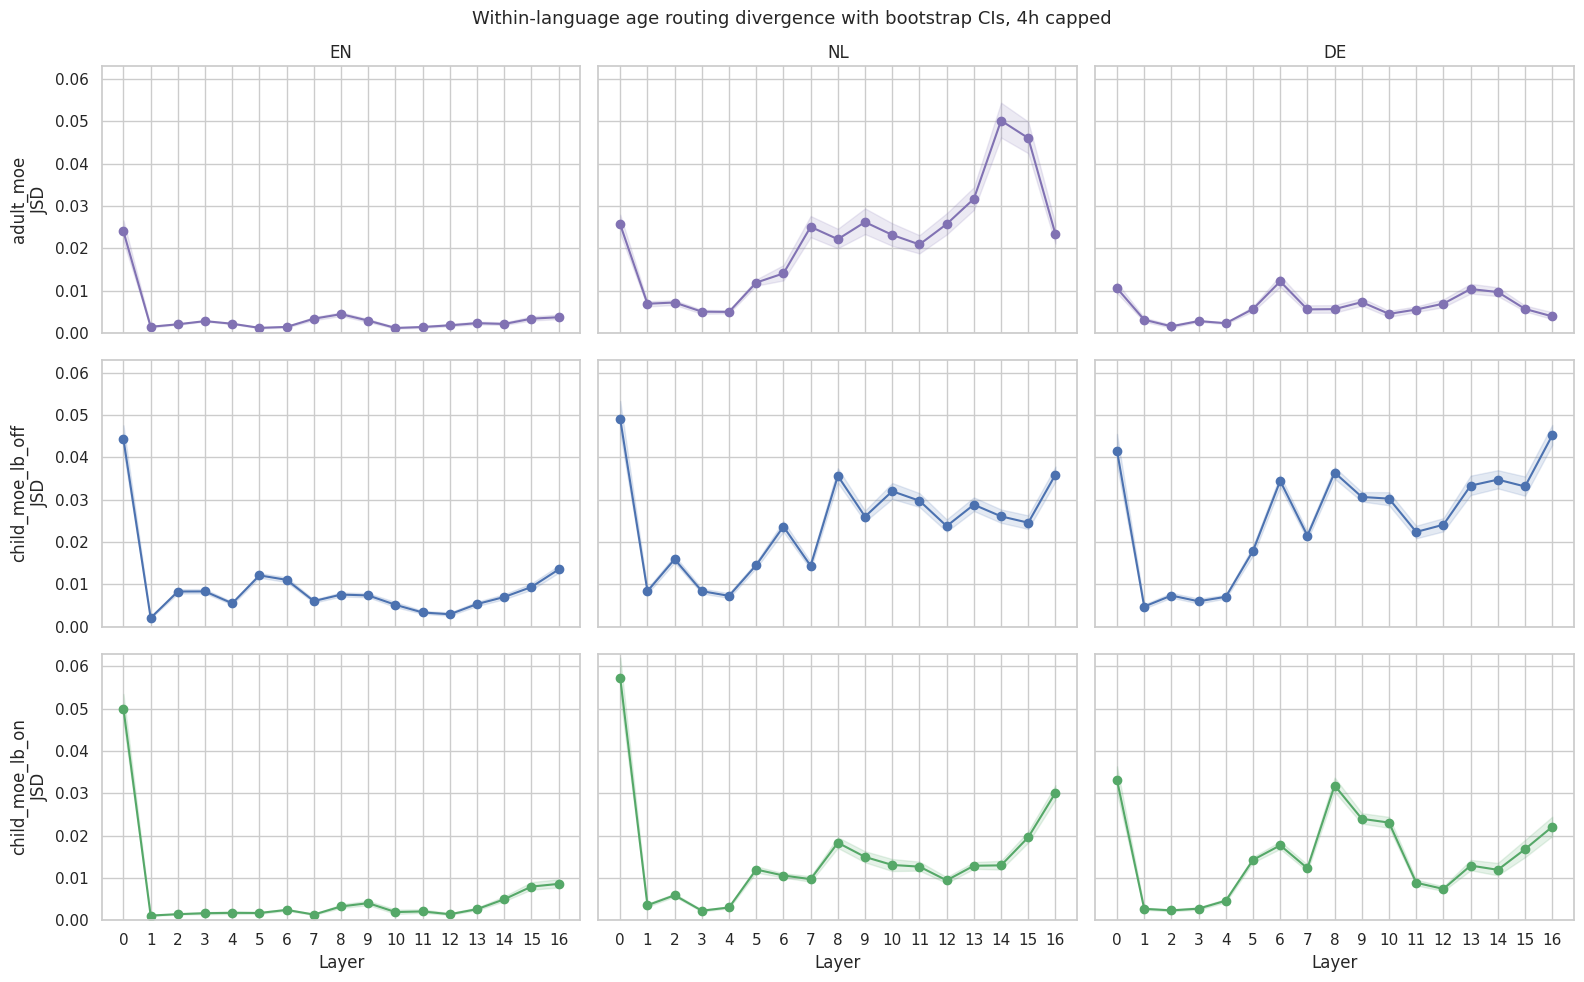

In [15]:
# %%
# Cell 8: Age JSD with CIs — per model × per language

fig, axes = plt.subplots(
    len(MODEL_NAMES),
    len(AGE_LANGUAGES),
    figsize=(16, 10),
    sharex=True,
    sharey=True,
)

for r, model_name in enumerate(MODEL_NAMES):
    for c, lang in enumerate(AGE_LANGUAGES):
        ax = axes[r, c]

        vals = age_jsd_observed[(model_name, lang)]
        ci = age_jsd_ci.get((model_name, lang))

        color = MODEL_COLORS[model_name]

        ax.plot(range(NUM_LAYERS), vals, marker="o", color=color)

        if ci is not None:
            ax.fill_between(
                ci["layer"],
                ci["ci_low"],
                ci["ci_high"],
                alpha=0.15,
                color=color,
            )

        ax.set_ylim(0, age_ymax)
        ax.set_xticks(range(NUM_LAYERS))

        if r == 0:
            ax.set_title(lang.upper())

        if c == 0:
            ax.set_ylabel(f"{model_name}\nJSD")

        if r == len(MODEL_NAMES) - 1:
            ax.set_xlabel("Layer")

plt.suptitle("Within-language age routing divergence with bootstrap CIs, 4h capped", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "age_jsd_grid_models_languages_ci_4h.png", dpi=200)
plt.show()

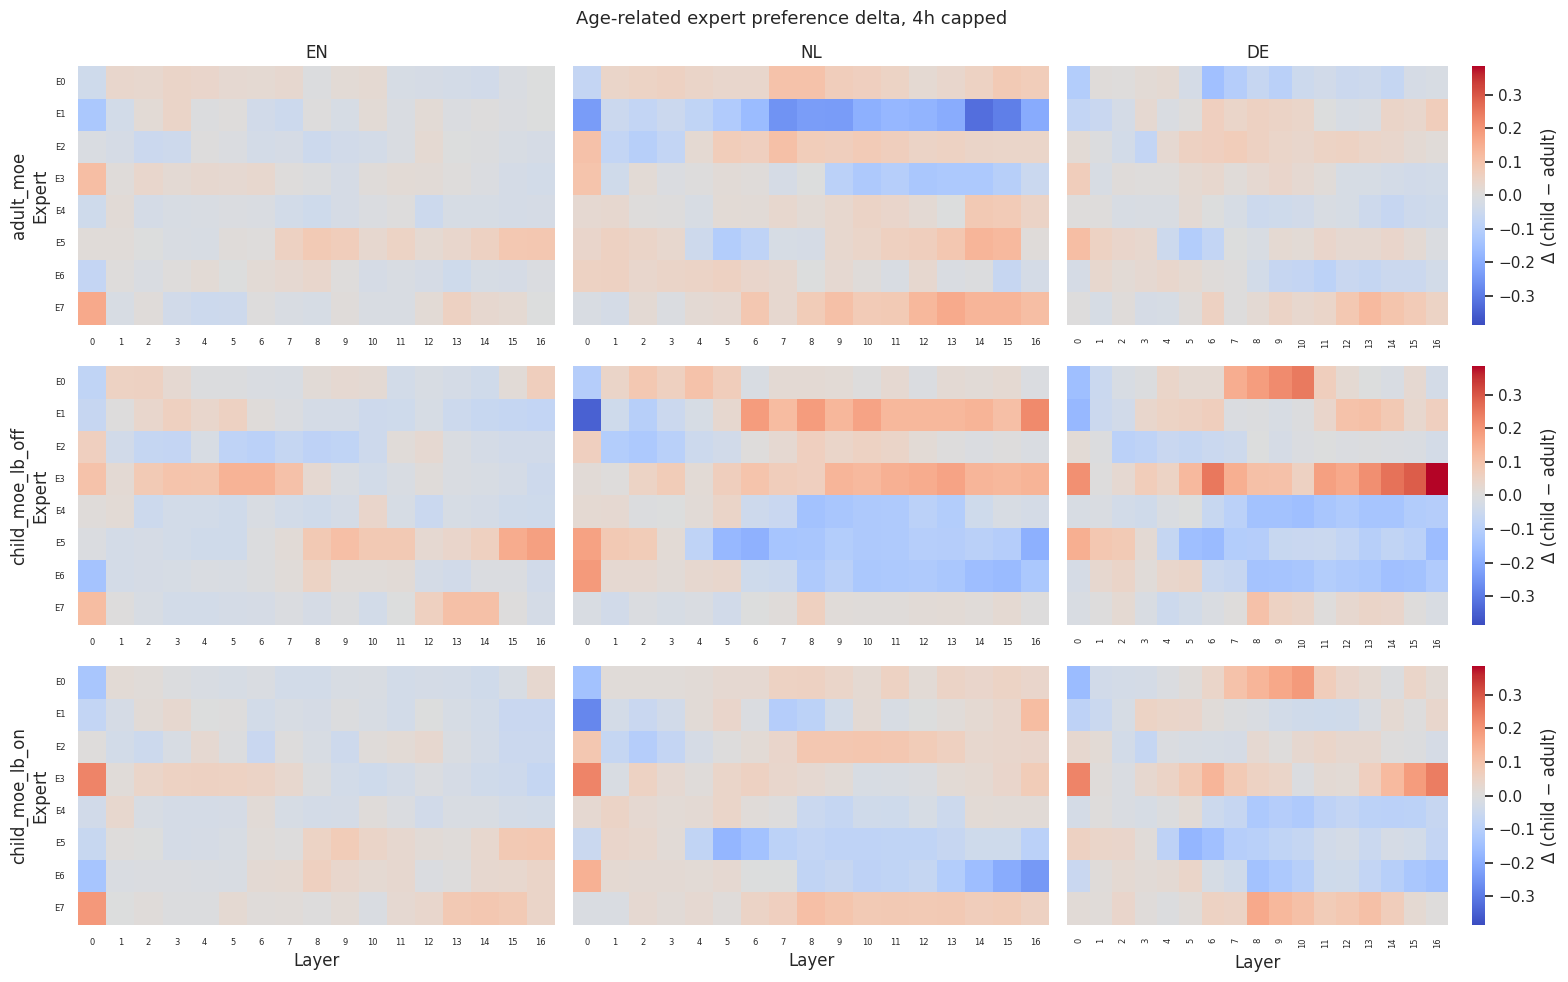

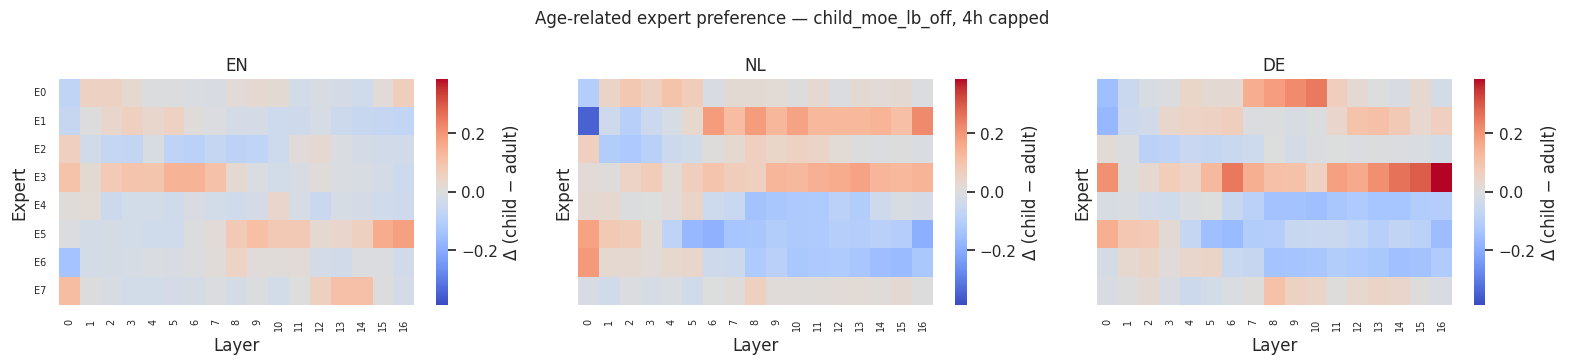

In [16]:
# %%
# Cell 9: Age specialization — expert preference delta per model and language
#
# Delta = child load - adult load.
# One grid: rows=models, columns=languages.

age_delta = {}

for model_name in MODEL_NAMES:
    md = distributions.get(model_name, {})

    for lang in AGE_LANGUAGES:
        mat = np.full((NUM_EXPERTS, NUM_LAYERS), np.nan)

        for layer in range(NUM_LAYERS):
            ld = md.get(layer, {})
            adult = ld.get((lang, "adult"))
            child = ld.get((lang, "child"))

            if adult is not None and child is not None:
                mat[:, layer] = (child - adult) * TOP_K

        age_delta[(model_name, lang)] = mat


all_delta_vals = np.concatenate([m.ravel() for m in age_delta.values()])
all_delta_vals = all_delta_vals[~np.isnan(all_delta_vals)]

max_abs = np.max(np.abs(all_delta_vals)) if all_delta_vals.size else 1e-6
if max_abs == 0:
    max_abs = 1e-6


fig, axes = plt.subplots(
    len(MODEL_NAMES),
    len(AGE_LANGUAGES),
    figsize=(16, 10),
    sharey=True,
)

for r, model_name in enumerate(MODEL_NAMES):
    for c, lang in enumerate(AGE_LANGUAGES):
        ax = axes[r, c]
        mat = age_delta[(model_name, lang)]

        sns.heatmap(
            mat,
            cmap="coolwarm",
            center=0,
            vmin=-max_abs,
            vmax=max_abs,
            ax=ax,
            cbar=(c == len(AGE_LANGUAGES) - 1),
            cbar_kws={"label": "Δ (child − adult)"} if c == len(AGE_LANGUAGES) - 1 else {},
        )

        if r == 0:
            ax.set_title(lang.upper())

        if c == 0:
            ax.set_ylabel(f"{model_name}\nExpert")
        else:
            ax.set_ylabel("")

        ax.set_xlabel("Layer" if r == len(MODEL_NAMES) - 1 else "")
        ax.set_xticks(np.arange(NUM_LAYERS) + 0.5)
        ax.set_xticklabels(range(NUM_LAYERS), fontsize=6)
        ax.set_yticklabels([f"E{i}" for i in range(NUM_EXPERTS)], rotation=0, fontsize=6)

plt.suptitle("Age-related expert preference delta, 4h capped", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "age_delta_grid_models_languages_4h.png", dpi=200)
plt.show()


# Cleaner thesis figure: primary model only.
fig, axes = plt.subplots(1, len(AGE_LANGUAGES), figsize=(16, 3.7), sharey=True)

for ax, lang in zip(axes, AGE_LANGUAGES):
    mat = age_delta[(PRIMARY_MODEL, lang)]

    sns.heatmap(
        mat,
        cmap="coolwarm",
        center=0,
        vmin=-max_abs,
        vmax=max_abs,
        ax=ax,
        cbar_kws={"label": "Δ (child − adult)"},
    )

    ax.set_title(f"{lang.upper()}")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Expert")
    ax.set_xticks(np.arange(NUM_LAYERS) + 0.5)
    ax.set_xticklabels(range(NUM_LAYERS), fontsize=7)
    ax.set_yticklabels([f"E{i}" for i in range(NUM_EXPERTS)], rotation=0, fontsize=7)

plt.suptitle(f"Age-related expert preference — {PRIMARY_MODEL}, 4h capped", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "age_delta_per_language_primary_4h.png", dpi=200)
plt.show()

Peak layers per language: {'en': 0, 'nl': 0, 'de': 16}
Key layers: [0, 4, 5, 16]


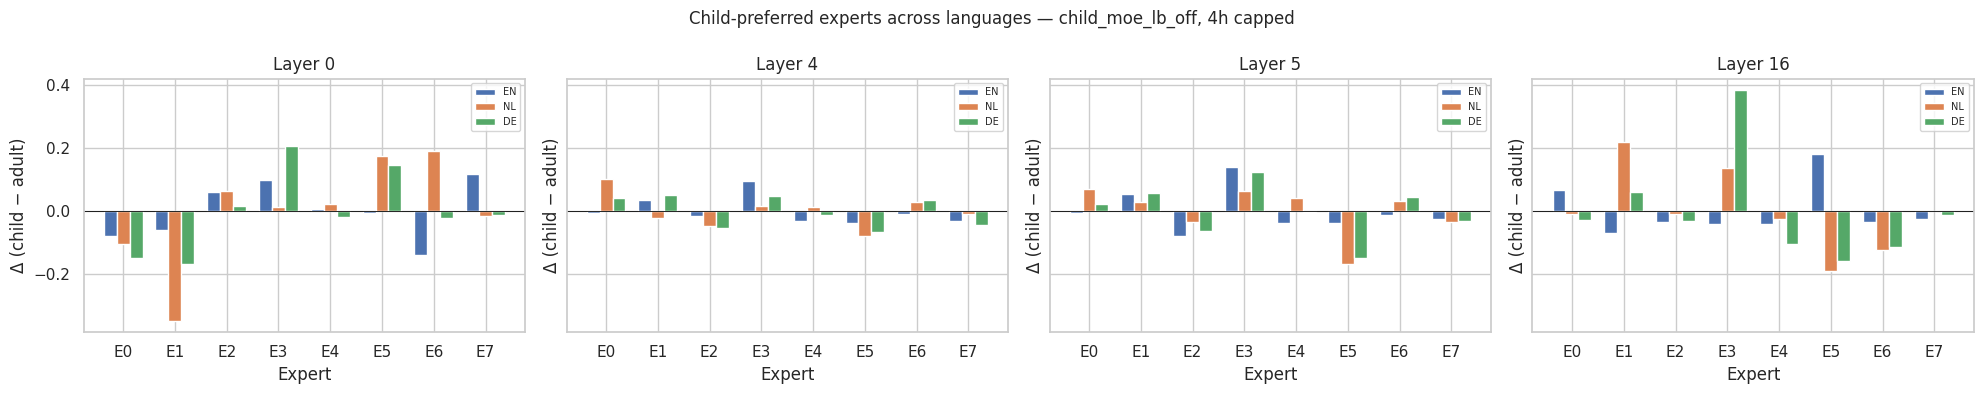


Child-preferred experts at key layers:
Layer 0:
  EN: E2, E3, E4, E7
  NL: E2, E3, E4, E5, E6
  DE: E2, E3, E5
Layer 4:
  EN: E1, E3
  NL: E0, E3, E4, E6
  DE: E0, E1, E3, E6
Layer 5:
  EN: E1, E3
  NL: E0, E1, E3, E4, E6
  DE: E0, E1, E3, E6
Layer 16:
  EN: E0, E5
  NL: E1, E3, E7
  DE: E1, E3


In [17]:
# %%
# Cell 10: Cross-tabulation of child-preferred experts
#
# Uses primary model.
# Key layers are selected from peak age-JSD layers per language.

peak_layers = {}

for lang in AGE_LANGUAGES:
    vals = age_jsd_observed.get((PRIMARY_MODEL, lang), [])
    valid = [(i, v) for i, v in enumerate(vals) if not np.isnan(v)]

    if valid:
        peak_layers[lang] = max(valid, key=lambda x: x[1])[0]

print("Peak layers per language:", peak_layers)

key_layers = sorted(set(peak_layers.values()))

# Add English-like peak layers if too few unique peaks.
for fallback in [4, 5, 13, 14]:
    if len(key_layers) >= 4:
        break
    if fallback not in key_layers:
        key_layers.append(fallback)

key_layers = sorted(key_layers)[:4]
print("Key layers:", key_layers)


fig, axes = plt.subplots(1, len(key_layers), figsize=(5 * len(key_layers), 4), sharey=True)

if len(key_layers) == 1:
    axes = [axes]

x = np.arange(NUM_EXPERTS)
width = 0.25

for ax, layer in zip(axes, key_layers):
    for i, lang in enumerate(AGE_LANGUAGES):
        mat = age_delta[(PRIMARY_MODEL, lang)]
        deltas = mat[:, layer]

        ax.bar(
            x + i * width,
            deltas,
            width,
            label=lang.upper(),
            color=LANG_COLORS[lang],
        )

    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_title(f"Layer {layer}")
    ax.set_xlabel("Expert")
    ax.set_ylabel("Δ (child − adult)")
    ax.set_xticks(x + width)
    ax.set_xticklabels([f"E{i}" for i in range(NUM_EXPERTS)])
    ax.legend(fontsize=7)

plt.suptitle(f"Child-preferred experts across languages — {PRIMARY_MODEL}, 4h capped", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cross_tabulation_delta_4h.png", dpi=200)
plt.show()


print("\nChild-preferred experts at key layers:")
for layer in key_layers:
    print(f"Layer {layer}:")
    for lang in AGE_LANGUAGES:
        mat = age_delta[(PRIMARY_MODEL, lang)]
        child_pref = [f"E{e}" for e in range(NUM_EXPERTS) if mat[e, layer] > 0]
        print(f"  {lang.upper()}: {', '.join(child_pref) if child_pref else 'none'}")

Peak layers per language: {'en': 0, 'nl': 0, 'de': 16}
Key layers: [0, 4, 5, 16]


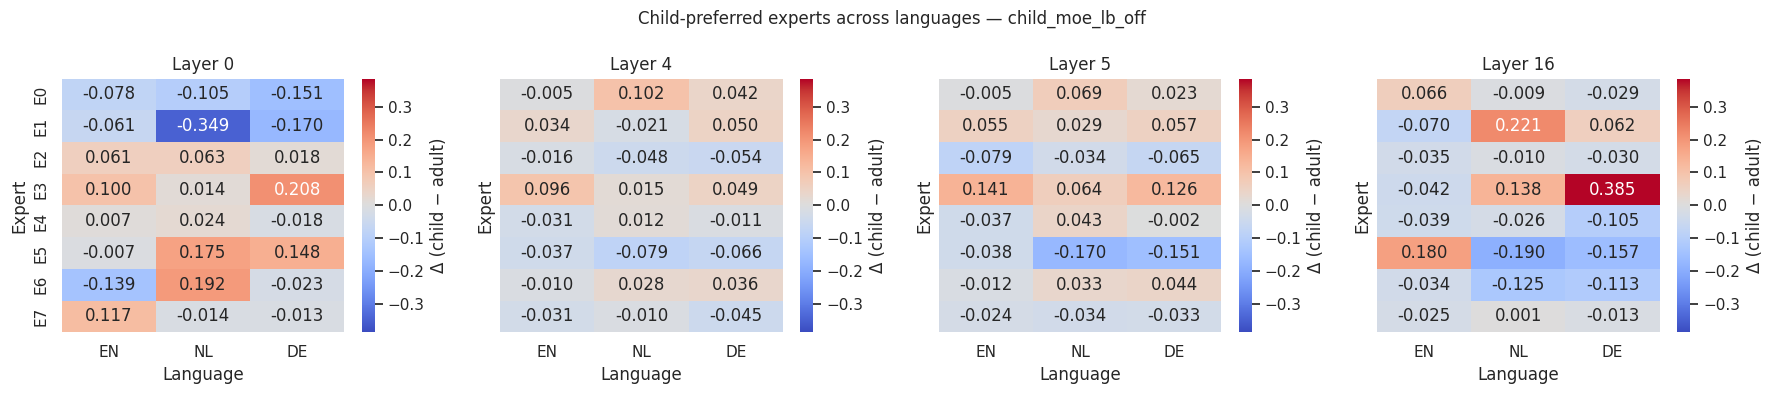


Child-preferred experts (Δ > 0) at key layers:
  Layer 0:
    EN: E2, E3, E4, E7
    NL: E2, E3, E4, E5, E6
    DE: E2, E3, E5
  Layer 4:
    EN: E1, E3
    NL: E0, E3, E4, E6
    DE: E0, E1, E3, E6
  Layer 5:
    EN: E1, E3
    NL: E0, E1, E3, E4, E6
    DE: E0, E1, E3, E6
  Layer 16:
    EN: E0, E5
    NL: E1, E3, E7
    DE: E1, E3


In [20]:
# %%
# Cell 10: Cross-tabulation of child-preferred experts — heatmaps
#
# At key layers, show expert × language heatmap of Δ values.
# Red = child-preferred, blue = adult-preferred.

peak_layers = {}
for lang in AGE_LANGUAGES:
    vals = age_jsd_observed.get((PRIMARY_MODEL, lang), [])
    valid = [(i, v) for i, v in enumerate(vals) if not np.isnan(v)]
    if valid:
        peak_layers[lang] = max(valid, key=lambda x: x[1])[0]

print("Peak layers per language:", peak_layers)

key_layers = sorted(set(peak_layers.values()))
for fallback in [4, 5, 13, 14]:
    if len(key_layers) >= 4:
        break
    if fallback not in key_layers:
        key_layers.append(fallback)
key_layers = sorted(key_layers)[:4]
print("Key layers:", key_layers)

# Build one (experts × languages) matrix per key layer
crosstab_mats = {}
for layer in key_layers:
    mat = np.full((NUM_EXPERTS, len(AGE_LANGUAGES)), np.nan)
    for c, lang in enumerate(AGE_LANGUAGES):
        delta_mat = age_delta.get((PRIMARY_MODEL, lang))
        if delta_mat is not None:
            mat[:, c] = delta_mat[:, layer]
    crosstab_mats[layer] = mat

# Shared color scale
all_ct = np.concatenate([m.ravel() for m in crosstab_mats.values()])
ct_max = np.nanmax(np.abs(all_ct))
if ct_max == 0:
    ct_max = 1e-6

fig, axes = plt.subplots(1, len(key_layers), figsize=(4.5 * len(key_layers), 4), sharey=True)
if len(key_layers) == 1:
    axes = [axes]

for ax, layer in zip(axes, key_layers):
    mat = crosstab_mats[layer]
    sns.heatmap(
        mat,
        cmap="coolwarm",
        center=0,
        vmin=-ct_max,
        vmax=ct_max,
        annot=True,
        fmt=".3f",
        ax=ax,
        xticklabels=[l.upper() for l in AGE_LANGUAGES],
        yticklabels=[f"E{i}" for i in range(NUM_EXPERTS)],
        cbar_kws={"label": "Δ (child − adult)"},
    )
    ax.set_title(f"Layer {layer}")
    ax.set_xlabel("Language")
    ax.set_ylabel("Expert")

plt.suptitle(f"Child-preferred experts across languages — {PRIMARY_MODEL}", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cross_tabulation_heatmap_4h.png", dpi=200)
plt.show()

# Print summary
print("\nChild-preferred experts (Δ > 0) at key layers:")
for layer in key_layers:
    print(f"  Layer {layer}:")
    for lang in AGE_LANGUAGES:
        mat = age_delta.get((PRIMARY_MODEL, lang))
        if mat is None:
            continue
        child_pref = [f"E{e}" for e in range(NUM_EXPERTS) if mat[e, layer] > 0]
        print(f"    {lang.upper()}: {', '.join(child_pref) if child_pref else 'none'}")

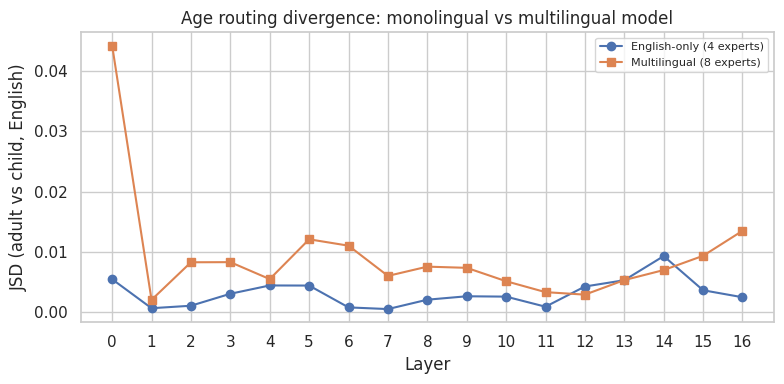

  English-only peak: JSD=0.009318 at layer 14
  Multilingual peak: JSD=0.044262 at layer 0


In [18]:
# %%
# Cell 11: English-only vs multilingual model comparison

EN_ONLY_NUM_EXPERTS = 4
en_only_prob_cols = [f"expert_{i}_prob" for i in range(EN_ONLY_NUM_EXPERTS)]

if en_only_df is not None:
    en_only_jsd = []
    for layer in range(NUM_LAYERS):
        layer_df = en_only_df[en_only_df["layer_idx"] == layer]
        adult_df = layer_df[layer_df["age_group"] == "adult"]
        child_df = layer_df[layer_df["age_group"] == "child"]

        if adult_df.empty or child_df.empty:
            en_only_jsd.append(np.nan)
            continue

        a_probs = adult_df[en_only_prob_cols].values.astype(float)
        c_probs = child_df[en_only_prob_cols].values.astype(float)

        if "duration_sec" in adult_df.columns:
            a_w = adult_df["duration_sec"].values.astype(float)
            c_w = child_df["duration_sec"].values.astype(float)
            a_tot = (a_probs * a_w[:, None]).sum(axis=0)
            c_tot = (c_probs * c_w[:, None]).sum(axis=0)
        else:
            a_tot = a_probs.sum(axis=0)
            c_tot = c_probs.sum(axis=0)

        a_dist = a_tot / a_tot.sum()
        c_dist = c_tot / c_tot.sum()
        en_only_jsd.append(jsd(a_dist, c_dist))

    ml_en_jsd = age_jsd_observed.get((PRIMARY_MODEL, "en"), [np.nan] * NUM_LAYERS)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(NUM_LAYERS), en_only_jsd, marker="o", label="English-only (4 experts)")
    ax.plot(range(NUM_LAYERS), ml_en_jsd, marker="s", label="Multilingual (8 experts)")
    ax.set_xlabel("Layer")
    ax.set_ylabel("JSD (adult vs child, English)")
    ax.set_title("Age routing divergence: monolingual vs multilingual model")
    ax.set_xticks(range(NUM_LAYERS))
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "en_only_vs_multilingual_jsd.png", dpi=150)
    plt.show()

    en_peak = max(enumerate(en_only_jsd), key=lambda x: x[1] if not np.isnan(x[1]) else -1)
    ml_peak = max(enumerate(ml_en_jsd), key=lambda x: x[1] if not np.isnan(x[1]) else -1)
    print(f"  English-only peak: JSD={en_peak[1]:.6f} at layer {en_peak[0]}")
    print(f"  Multilingual peak: JSD={ml_peak[1]:.6f} at layer {ml_peak[0]}")
else:
    print("Missing English-only data; skipping comparison.")

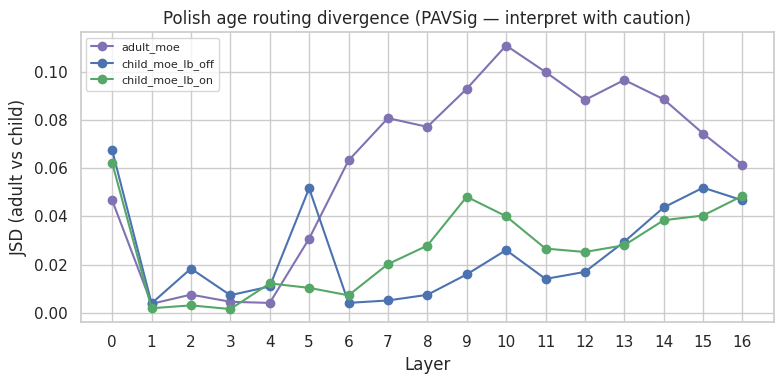

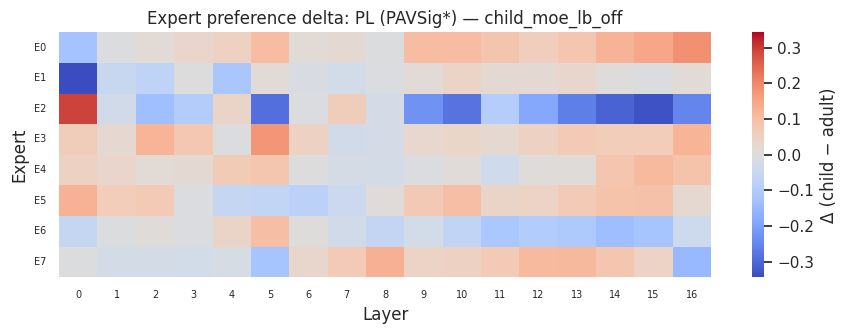

In [19]:
# %%
# Cell 12: PAVSig — Polish age analysis (with caveats)
#
# PAVSig is a clinical corpus of children with sigmatism.
# Results cannot be attributed to typical child speech acoustics.

has_pl_child = any(
    ("pl", "child") in distributions.get(model_name, {}).get(layer, {})
    for model_name in MODEL_NAMES
    for layer in range(NUM_LAYERS)
)

if not has_pl_child:
    print("No Polish child (PAVSig) data found. Skipping.")
    print("Fix PAVSig manifest path and rerun extraction.")
else:
    # JSD per model
    pl_jsd_by_model = {}
    for model_name in MODEL_NAMES:
        md = distributions.get(model_name, {})
        vals = []
        for layer in range(NUM_LAYERS):
            ld = md.get(layer, {})
            adult = ld.get(("pl", "adult"))
            child = ld.get(("pl", "child"))
            vals.append(jsd(adult, child) if adult is not None and child is not None else np.nan)
        pl_jsd_by_model[model_name] = vals

    # JSD plot — all 3 models
    fig, ax = plt.subplots(figsize=(8, 4))
    for model_name in MODEL_NAMES:
        ax.plot(range(NUM_LAYERS), pl_jsd_by_model[model_name],
                marker="o", label=model_name, color=MODEL_COLORS[model_name])
    ax.set_xlabel("Layer")
    ax.set_ylabel("JSD (adult vs child)")
    ax.set_title("Polish age routing divergence (PAVSig — interpret with caution)")
    ax.set_xticks(range(NUM_LAYERS))
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "pavsig_polish_jsd.png", dpi=150)
    plt.show()

    # Delta heatmap — primary model
    pl_delta = np.full((NUM_EXPERTS, NUM_LAYERS), np.nan)
    md = distributions.get(PRIMARY_MODEL, {})
    for layer in range(NUM_LAYERS):
        ld = md.get(layer, {})
        adult = ld.get(("pl", "adult"))
        child = ld.get(("pl", "child"))
        if adult is not None and child is not None:
            pl_delta[:, layer] = (child - adult) * TOP_K

    fig, ax = plt.subplots(figsize=(9, 3.5))
    pmax = np.nanmax(np.abs(pl_delta))
    if pmax == 0:
        pmax = 1e-6
    sns.heatmap(
        pl_delta, cmap="coolwarm", center=0, vmin=-pmax, vmax=pmax, ax=ax,
        cbar_kws={"label": "Δ (child − adult)"},
    )
    ax.set_title(f"Expert preference delta: PL (PAVSig*) — {PRIMARY_MODEL}")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Expert")
    ax.set_xticks(np.arange(NUM_LAYERS) + 0.5)
    ax.set_xticklabels(range(NUM_LAYERS), fontsize=7)
    ax.set_yticklabels([f"E{i}" for i in range(NUM_EXPERTS)], rotation=0, fontsize=7)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "pavsig_polish_delta.png", dpi=150)
    plt.show()

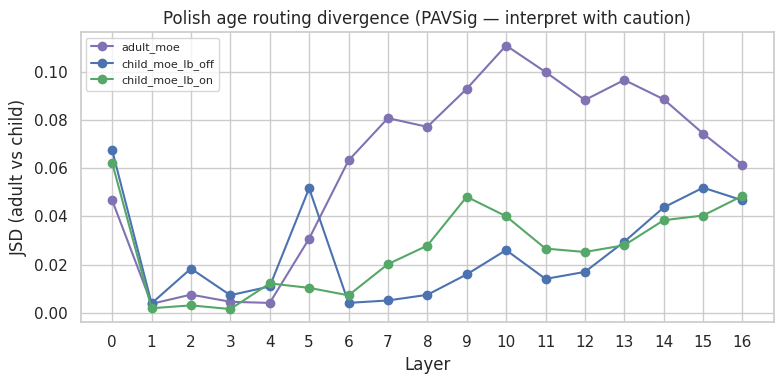

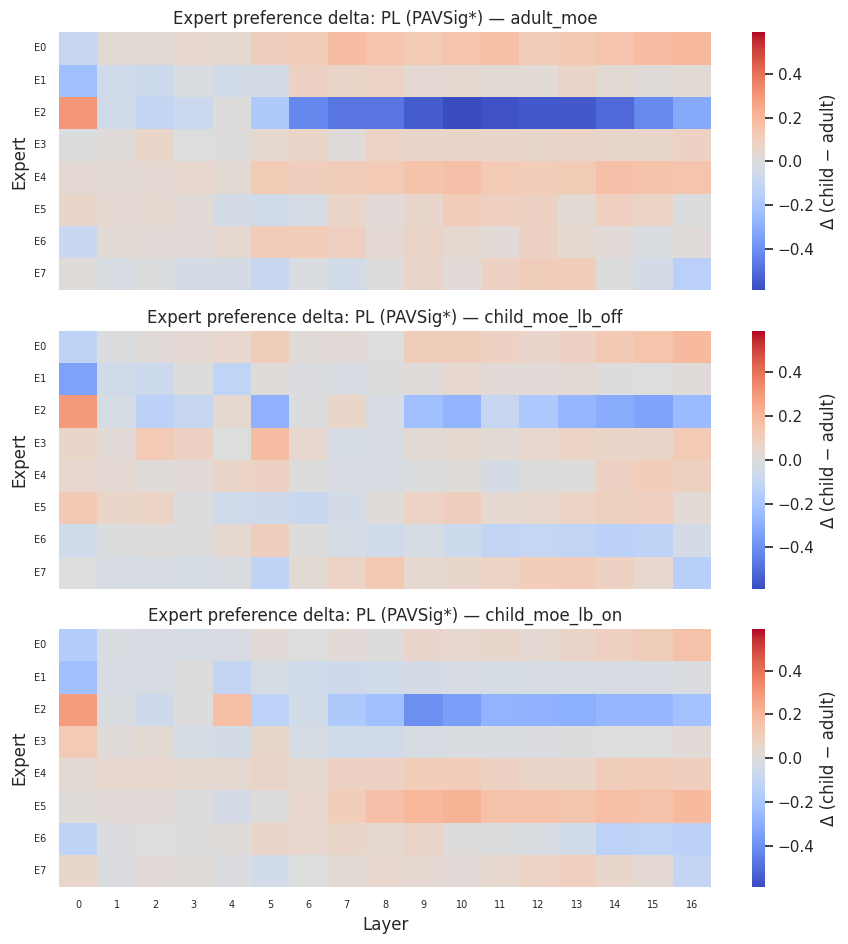


PAVSig Polish summary:
           model  peak_jsd_layer  peak_jsd  child_pref_expert_at_peak  adult_pref_expert_at_peak  max_delta_at_peak  min_delta_at_peak
       adult_moe              10  0.110952                          4                          2           0.165538          -0.588661
child_moe_lb_off               0  0.067558                          2                          1           0.293183          -0.343381
 child_moe_lb_on               0  0.062317                          2                          1           0.288934          -0.228146


In [21]:
# %%
# Cell 12: PAVSig — Polish age analysis (with caveats)
#
# PAVSig is a clinical corpus of children with sigmatism.
# Results cannot be attributed to typical child speech acoustics.

has_pl_child = any(
    ("pl", "child") in distributions.get(model_name, {}).get(layer, {})
    for model_name in MODEL_NAMES
    for layer in range(NUM_LAYERS)
)

if not has_pl_child:
    print("No Polish child (PAVSig) data found. Skipping.")
    print("Fix PAVSig manifest path and rerun extraction.")

else:
    # ------------------------------------------------------------
    # 1. JSD per model
    # ------------------------------------------------------------
    pl_jsd_by_model = {}

    for model_name in MODEL_NAMES:
        md = distributions.get(model_name, {})
        vals = []

        for layer in range(NUM_LAYERS):
            ld = md.get(layer, {})
            adult = ld.get(("pl", "adult"))
            child = ld.get(("pl", "child"))

            vals.append(jsd(adult, child) if adult is not None and child is not None else np.nan)

        pl_jsd_by_model[model_name] = vals

    # Plot JSD curves for all models
    fig, ax = plt.subplots(figsize=(8, 4))

    for model_name in MODEL_NAMES:
        ax.plot(
            range(NUM_LAYERS),
            pl_jsd_by_model[model_name],
            marker="o",
            label=model_name,
            color=MODEL_COLORS[model_name],
        )

    ax.set_xlabel("Layer")
    ax.set_ylabel("JSD (adult vs child)")
    ax.set_title("Polish age routing divergence (PAVSig — interpret with caution)")
    ax.set_xticks(range(NUM_LAYERS))
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "pavsig_polish_jsd_all_models.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ------------------------------------------------------------
    # 2. Expert preference delta per model
    # ------------------------------------------------------------
    pl_delta_by_model = {}

    for model_name in MODEL_NAMES:
        md = distributions.get(model_name, {})
        mat = np.full((NUM_EXPERTS, NUM_LAYERS), np.nan)

        for layer in range(NUM_LAYERS):
            ld = md.get(layer, {})
            adult = ld.get(("pl", "adult"))
            child = ld.get(("pl", "child"))

            if adult is not None and child is not None:
                mat[:, layer] = (child - adult) * TOP_K

        pl_delta_by_model[model_name] = mat

    # Shared color scale across all three models
    all_vals = np.concatenate([m.ravel() for m in pl_delta_by_model.values()])
    all_vals = all_vals[~np.isnan(all_vals)]

    pmax = np.nanmax(np.abs(all_vals)) if all_vals.size else 1e-6
    if pmax == 0:
        pmax = 1e-6

    # Plot one heatmap per model
    fig, axes = plt.subplots(
        nrows=len(MODEL_NAMES),
        ncols=1,
        figsize=(9, 3.2 * len(MODEL_NAMES)),
        sharex=True,
        sharey=True,
    )

    if len(MODEL_NAMES) == 1:
        axes = [axes]

    for ax, model_name in zip(axes, MODEL_NAMES):
        mat = pl_delta_by_model[model_name]

        sns.heatmap(
            mat,
            cmap="coolwarm",
            center=0,
            vmin=-pmax,
            vmax=pmax,
            ax=ax,
            cbar_kws={"label": "Δ (child − adult)"},
        )

        ax.set_title(f"Expert preference delta: PL (PAVSig*) — {model_name}")
        ax.set_ylabel("Expert")
        ax.set_xticks(np.arange(NUM_LAYERS) + 0.5)
        ax.set_xticklabels(range(NUM_LAYERS), fontsize=7)
        ax.set_yticklabels([f"E{i}" for i in range(NUM_EXPERTS)], rotation=0, fontsize=7)

    axes[-1].set_xlabel("Layer")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "pavsig_polish_delta_all_models.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ------------------------------------------------------------
    # 3. Optional summary table
    # ------------------------------------------------------------
    summary_rows = []

    for model_name in MODEL_NAMES:
        vals = np.array(pl_jsd_by_model[model_name], dtype=float)

        if np.all(np.isnan(vals)):
            peak_layer = np.nan
            peak_jsd = np.nan
        else:
            peak_layer = int(np.nanargmax(vals))
            peak_jsd = float(np.nanmax(vals))

        mat = pl_delta_by_model[model_name]

        if np.all(np.isnan(mat)):
            child_pref_expert = np.nan
            adult_pref_expert = np.nan
            max_delta = np.nan
            min_delta = np.nan
        else:
            peak_mat = mat[:, peak_layer]
            child_pref_expert = int(np.nanargmax(peak_mat))
            adult_pref_expert = int(np.nanargmin(peak_mat))
            max_delta = float(np.nanmax(peak_mat))
            min_delta = float(np.nanmin(peak_mat))

        summary_rows.append(
            {
                "model": model_name,
                "peak_jsd_layer": peak_layer,
                "peak_jsd": peak_jsd,
                "child_pref_expert_at_peak": child_pref_expert,
                "adult_pref_expert_at_peak": adult_pref_expert,
                "max_delta_at_peak": max_delta,
                "min_delta_at_peak": min_delta,
            }
        )

    pl_summary = pd.DataFrame(summary_rows)
    pl_summary.to_csv(OUTPUT_DIR / "pavsig_polish_summary_all_models.csv", index=False)

    print("\nPAVSig Polish summary:")
    print(pl_summary.to_string(index=False))